In [30]:
import numpy as np
import pandas as pd
from fractions import Fraction
from math import floor, gcd, log, ceil
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UnitaryGate, QFT
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import time
import matplotlib.pyplot as plt
def build_mod_mult_unitary(k, N, n_bits):
    """Build the unitary matrix for 'multiply by k mod N'.
    
    Each input state |x> maps to |x*k mod N> for valid inputs.
    This is a permutation matrix — always unitary.
    """
    dim = 2**n_bits
    U = np.zeros((dim, dim))
    for x in range(dim):
        if x == 0:
            U[0][0] = 1                      # 0 maps to 0
        elif x < N and gcd(x, N) == 1:
            y = (x * k) % N                  # Valid input: multiply mod N
            U[y][x] = 1
        else:
            U[x][x] = 1                      # Out-of-range: identity
    return U

def build_shor_circuit(N, a, num_control, num_target):
    """Build the complete Shor's circuit with named registers.
    
    Returns the circuit and the number of controlled multiplications applied.
    """
    # Named registers for clear circuit diagrams
    control = QuantumRegister(num_control, name="Counting")
    target = QuantumRegister(num_target, name="Target")
    output = ClassicalRegister(num_control, name="output")
    circuit = QuantumCircuit(control, target, output)
    
    # Step 1: Initialise target register to |1>
    circuit.x(num_control)  # Set first target qubit to |1>
    
    # Step 2: Hadamard on all counting qubits (creates superposition)
    for k in range(num_control):
        circuit.h(k)
    
    circuit.barrier()
    
    # Step 3: Controlled modular exponentiation
    n_mod_mults = 0
    for k in range(num_control):
        # Compute what constant this qubit multiplies by
        power = pow(a, 2**k, N)
        
        if power == 1:
            continue  # Multiplying by 1 does nothing, skip
        
        # Build unitary gate for this multiplication
        U = build_mod_mult_unitary(power, N, num_target)
        gate = UnitaryGate(U)
        gate.name = f"M_{power}"
        
        # Make it controlled by counting qubit k
        c_gate = gate.control()
        circuit.compose(c_gate, qubits=[k] + list(range(num_control, num_control + num_target)), inplace=True)
        n_mod_mults += 1
    
    circuit.barrier()
    
    # Step 4: Inverse QFT on counting register
    circuit.compose(QFT(num_control, inverse=True), qubits=control, inplace=True)
    
    circuit.barrier()
    
    # Step 5: Measure counting register
    circuit.measure(control, output)
    
    return circuit, n_mod_mults

In [31]:
# For N=15, we need gates for "multiply by 2" and "multiply by 4"
# (other powers of a=2 reduce to 1 mod 15)
N = 15
num_target = ceil(log(N, 2))  # 4 qubits

print(f"Modular multiplication gates for N={N}:")
print(f"Target register: {num_target} qubits\n")

for k_val in [2, 4]:
    U = build_mod_mult_unitary(k_val, N, num_target)
    gate = UnitaryGate(U)
    gate.name = f"M_{k_val}"
    
    # Show the gate in a small circuit
    circ = QuantumCircuit(num_target)
    circ.append(gate, range(num_target))
    print(f"--- M_{k_val} (multiply by {k_val} mod {N}) ---")
    print(circ.draw(output='text'))
    print()

Modular multiplication gates for N=15:
Target register: 4 qubits

--- M_2 (multiply by 2 mod 15) ---
     ┌──────┐
q_0: ┤0     ├
     │      │
q_1: ┤1     ├
     │  M_2 │
q_2: ┤2     ├
     │      │
q_3: ┤3     ├
     └──────┘

--- M_4 (multiply by 4 mod 15) ---
     ┌──────┐
q_0: ┤0     ├
     │      │
q_1: ┤1     ├
     │  M_4 │
q_2: ┤2     ├
     │      │
q_3: ┤3     ├
     └──────┘



Shor's Algorithm Circuit: N=15, a=2
Counting qubits: 8, Target qubits: 4
Total qubits: 12

Counting qubit → Controlled multiplication:
  Qubit 0: a^(2^0) mod 15 = 2^1 mod 15 = 2
  Qubit 1: a^(2^1) mod 15 = 2^2 mod 15 = 4
  Qubit 2: a^(2^2) mod 15 = 2^4 mod 15 = 1 (skip: identity)
  Qubit 3: a^(2^3) mod 15 = 2^8 mod 15 = 1 (skip: identity)
  Qubit 4: a^(2^4) mod 15 = 2^16 mod 15 = 1 (skip: identity)
  Qubit 5: a^(2^5) mod 15 = 2^32 mod 15 = 1 (skip: identity)
  Qubit 6: a^(2^6) mod 15 = 2^64 mod 15 = 1 (skip: identity)
  Qubit 7: a^(2^7) mod 15 = 2^128 mod 15 = 1 (skip: identity)


C:\Users\User\AppData\Local\Temp\ipykernel_25740\3769653115.py:71: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit.compose(QFT(num_control, inverse=True), qubits=control, inplace=True)



Controlled multiplications applied: 2

Circuit diagram:


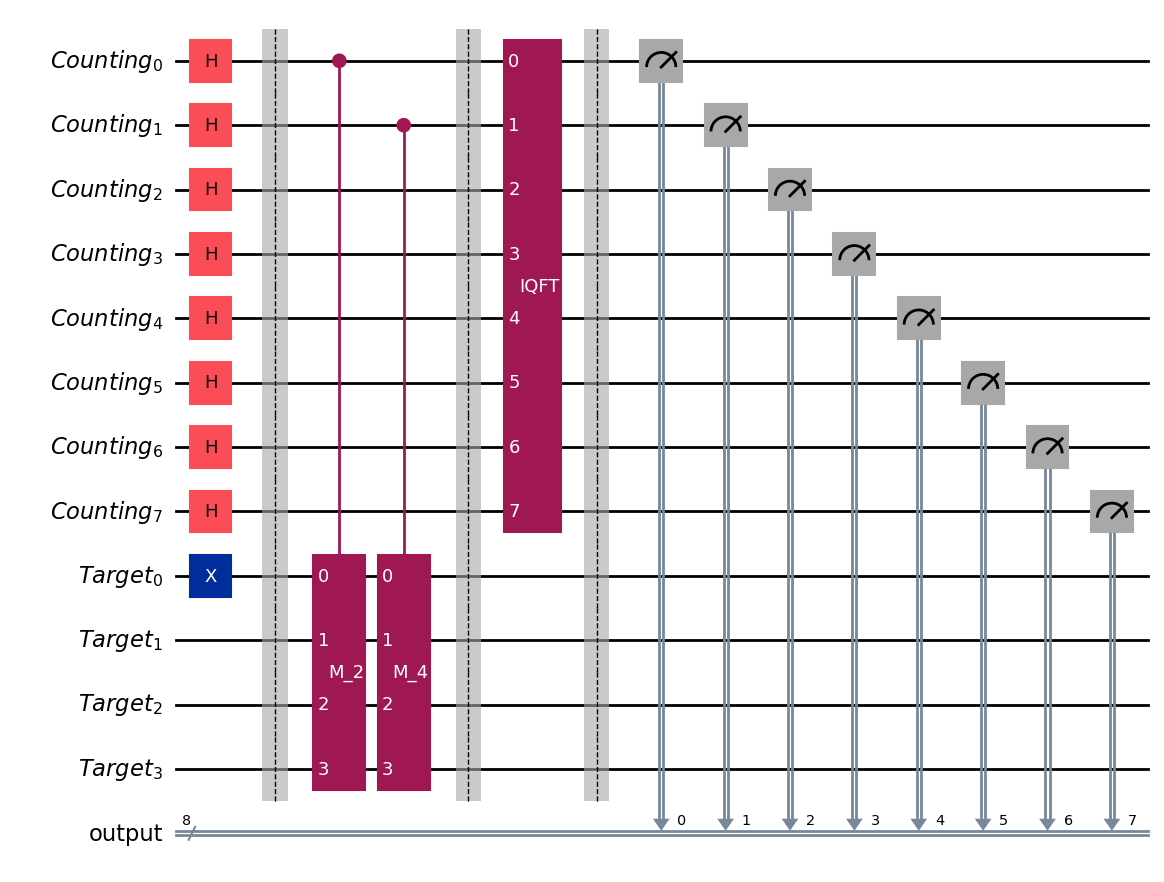

In [32]:
N = 15
a = 2
num_target = ceil(log(N, 2))         # 4 qubits for target register
num_control = 2 * num_target          # 8 qubits for counting register

print(f"Shor's Algorithm Circuit: N={N}, a={a}")
print(f"Counting qubits: {num_control}, Target qubits: {num_target}")
print(f"Total qubits: {num_control + num_target}\n")

# Show which modular multiplications each counting qubit controls
print("Counting qubit → Controlled multiplication:")
for k in range(num_control):
    power = pow(a, 2**k, N)
    skip = " (skip: identity)" if power == 1 else ""
    print(f"  Qubit {k}: a^(2^{k}) mod {N} = {a}^{2**k} mod {N} = {power}{skip}")

# Build the circuit
circuit_15, n_mults_15 = build_shor_circuit(N, a, num_control, num_target)

print(f"\nControlled multiplications applied: {n_mults_15}")
print(f"\nCircuit diagram:")
circuit_15.draw(output='mpl', fold=-1)

Transpiled circuit:
  Total gates: 1314
  Gate breakdown: {'u': 508, 'cx': 472, 'rz': 230, 'u2': 40, 'cp': 28, 'h': 16, 'measure': 8, 'swap': 4, 'barrier': 3, 'u3': 2, 'u1': 2, 'x': 1}
  Circuit depth: 927

  Simulation time: 48.8 ms (4096 shots)
  Time per shot: 0.0119 ms


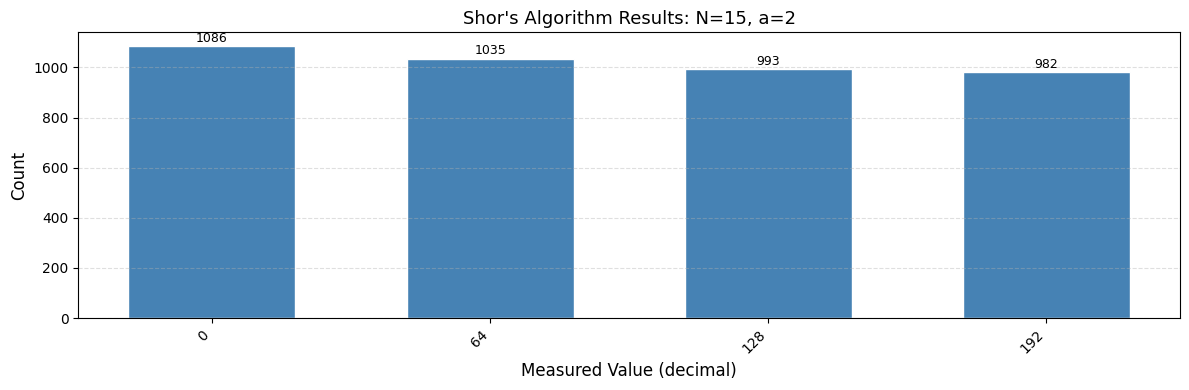

In [33]:
backend = AerSimulator()
compiled_15 = transpile(circuit_15, backend, optimization_level=1)

print(f"Transpiled circuit:")
print(f"  Total gates: {sum(compiled_15.count_ops().values())}")
print(f"  Gate breakdown: {dict(compiled_15.count_ops())}")
print(f"  Circuit depth: {compiled_15.depth()}")

# Run simulation
shots = 4096
start = time.perf_counter()
result = backend.run(compiled_15, shots=shots).result()
sim_time = (time.perf_counter() - start) * 1000

counts_15 = result.get_counts()
print(f"\n  Simulation time: {sim_time:.1f} ms ({shots} shots)")
print(f"  Time per shot: {sim_time/shots:.4f} ms")

# Show histogram of results
# Convert bitstrings to decimal and filter noise
decimal_counts = {int(k, 2): v for k, v in counts_15.items()}
filtered_counts = {k: v for k, v in sorted(decimal_counts.items()) if v > 10}

# Plot with decimal x-axis
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(range(len(filtered_counts)),
              list(filtered_counts.values()),
              color='steelblue', edgecolor='white', width=0.6)

for bar, count in zip(bars, filtered_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=9)

ax.set_xticks(range(len(filtered_counts)))
ax.set_xticklabels([str(k) for k in filtered_counts.keys()], rotation=45, ha='right', fontsize=10)
ax.set_xlabel('Measured Value (decimal)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f"Shor's Algorithm Results: N={N}, a={a}", fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [34]:
rows_phase = []
measured_phases = []

for bitstring in sorted(counts_15, key=lambda x: counts_15[x], reverse=True):
    count = counts_15[bitstring]
    decimal = int(bitstring, 2)
    phase = decimal / (2**num_control)
    measured_phases.append(phase)
    rows_phase.append([
        bitstring,
        decimal,
        count,
        f"{count/shots:.1%}",
        f"{decimal}/{2**num_control} = {phase:.4f}"
    ])

print(f"Phase extraction for N={N}, a={a}:")
df_phase = pd.DataFrame(rows_phase[:15],
    columns=["Bitstring", "Decimal", "Count", "Probability", "Phase"])
print(df_phase.to_string(index=False))

Phase extraction for N=15, a=2:
Bitstring  Decimal  Count Probability            Phase
 00000000        0   1086       26.5%   0/256 = 0.0000
 01000000       64   1035       25.3%  64/256 = 0.2500
 10000000      128    993       24.2% 128/256 = 0.5000
 11000000      192    982       24.0% 192/256 = 0.7500


In [35]:
rows_period = []
success_shots = 0

for bitstring in sorted(counts_15, key=lambda x: counts_15[x], reverse=True):
    count = counts_15[bitstring]
    decimal = int(bitstring, 2)
    phase = decimal / (2**num_control)
    
    frac = Fraction(phase).limit_denominator(N)
    r = frac.denominator
    
    # Validate period
    valid = r > 1 and pow(a, r, N) == 1
    
    # Try to extract factors
    factors = ""
    if valid and r % 2 == 0:
        x = pow(a, r // 2, N)
        if x != N - 1:
            f1, f2 = gcd(x - 1, N), gcd(x + 1, N)
            if 1 < f1 < N:
                factors = f"{f1} × {N // f1}"
                success_shots += count
            elif 1 < f2 < N:
                factors = f"{f2} × {N // f2}"
                success_shots += count
    
    rows_period.append([
        f"{phase:.4f}",
        f"{frac.numerator}/{frac.denominator}",
        r,
        "Yes" if valid else "No",
        count,
        factors if factors else "—"
    ])

print(f"Period extraction and factoring for N={N}, a={a}:")
df_period = pd.DataFrame(rows_period[:15],
    columns=["Phase", "Fraction", "Guess for r", "Valid", "Count", "Factors"])
print(df_period.to_string(index=False))

print(f"\nSuccess rate: {100*success_shots/shots:.1f}% ({success_shots}/{shots} shots)")
if success_shots > 0:
    print(f"Avg shots to first success: {round(shots/success_shots)}")

Period extraction and factoring for N=15, a=2:
 Phase Fraction  Guess for r Valid  Count Factors
0.0000      0/1            1    No   1086       —
0.2500      1/4            4   Yes   1035   3 × 5
0.5000      1/2            2    No    993       —
0.7500      3/4            4   Yes    982   3 × 5

Success rate: 49.2% (2017/4096 shots)
Avg shots to first success: 2


In [36]:
print("=" * 90)
print(f"SHOR'S ALGORITHM: N = 15 — ALL COPRIME BASES")
print("=" * 90)

N = 15
num_target = ceil(log(N, 2))
num_control = 2 * num_target
shots = 4096
bases_15 = [a for a in range(2, N) if gcd(a, N) == 1]

print(f"\nCoprime bases: {bases_15}")
print(f"Circuit: {num_control} counting + {num_target} target = {num_control + num_target} qubits, {shots} shots\n")

results_15 = []

for a in bases_15:
    # True period (for reference)
    val, true_r = a % N, 1
    while val != 1:
        val = (val * a) % N
        true_r += 1
    
    # Build and run
    circuit, n_mults = build_shor_circuit(N, a, num_control, num_target)
    compiled = transpile(circuit, AerSimulator(), optimization_level=1)
    
    start = time.perf_counter()
    result = AerSimulator().run(compiled, shots=shots).result()
    sim_time = (time.perf_counter() - start) * 1000
    
    counts = result.get_counts()
    gate_counts = compiled.count_ops()
    
    # Extract success rate
    success = 0
    factors_found = set()
    for bitstring, count in counts.items():
        phase = int(bitstring, 2) / (2**num_control)
        frac = Fraction(phase).limit_denominator(N)
        r = frac.denominator
        if r <= 1 or pow(a, r, N) != 1 or r % 2 != 0:
            continue
        x = pow(a, r // 2, N)
        if x == N - 1:
            continue
        f1, f2 = gcd(x - 1, N), gcd(x + 1, N)
        if 1 < f1 < N:
            factors_found.add((min(f1, N//f1), max(f1, N//f1)))
            success += count
        elif 1 < f2 < N:
            factors_found.add((min(f2, N//f2), max(f2, N//f2)))
            success += count
    
    sr = 100 * success / shots
    s2s = round(1 / (success/shots)) if success > 0 else None
    
    results_15.append({
        'a': a, 'true_r': true_r, 'n_mults': n_mults,
        'total_gates': sum(gate_counts.values()),
        'depth': compiled.depth(),
        'sim_time': sim_time,
        'success_rate': sr,
        'shots_to_1st': s2s,
        'factors': list(factors_found)
    })

# Display as table
rows = []
for r in results_15:
    f_str = str(r['factors'][0]) if r['factors'] else "—"
    s2s_str = str(r['shots_to_1st']) if r['shots_to_1st'] else "—"
    rows.append([r['a'], r['true_r'], r['n_mults'], r['total_gates'],
                 r['depth'], f"{r['sim_time']:.1f}", f"{r['success_rate']:.1f}%",
                 s2s_str, f_str])

df_15 = pd.DataFrame(rows,
    columns=["Base a", "Period r", "Ctrl Mults", "Total Gates", "Depth",
             "Sim Time (ms)", "Success Rate", "Shots to 1st", "Factors"])
print(df_15.to_string(index=False))

successful = [r for r in results_15 if r['factors']]
print(f"\nBases that found factors: {[r['a'] for r in successful]} ({len(successful)}/{len(bases_15)})")
if successful:
    print(f"Avg success rate: {np.mean([r['success_rate'] for r in successful]):.1f}%")

SHOR'S ALGORITHM: N = 15 — ALL COPRIME BASES

Coprime bases: [2, 4, 7, 8, 11, 13, 14]
Circuit: 8 counting + 4 target = 12 qubits, 4096 shots



C:\Users\User\AppData\Local\Temp\ipykernel_25740\3769653115.py:71: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit.compose(QFT(num_control, inverse=True), qubits=control, inplace=True)


 Base a  Period r  Ctrl Mults  Total Gates  Depth Sim Time (ms) Success Rate Shots to 1st Factors
      2         4           2         1314    927          61.9        49.9%            2  (3, 5)
      4         2           1          690    473          25.7        48.0%            2  (3, 5)
      7         4           2         1220    857          56.1        50.8%            2  (3, 5)
      8         4           2         1317    929          52.2        48.9%            2  (3, 5)
     11         2           1          687    472          24.6        50.7%            2  (3, 5)
     13         4           2         1220    857          82.8        49.4%            2  (3, 5)
     14         2           1          688    473          28.2         0.0%            —       —

Bases that found factors: [2, 4, 7, 8, 11, 13] (6/7)
Avg success rate: 49.6%


Shor's Algorithm Circuit: N=21, a=2
Counting qubits: 10, Target qubits: 5
Total qubits: 15

Counting qubit → Controlled multiplication:
  Qubit 0: a^(2^0) mod 21 = 2^1 mod 21 = 2
  Qubit 1: a^(2^1) mod 21 = 2^2 mod 21 = 4
  Qubit 2: a^(2^2) mod 21 = 2^4 mod 21 = 16
  Qubit 3: a^(2^3) mod 21 = 2^8 mod 21 = 4
  Qubit 4: a^(2^4) mod 21 = 2^16 mod 21 = 16
  Qubit 5: a^(2^5) mod 21 = 2^32 mod 21 = 4
  Qubit 6: a^(2^6) mod 21 = 2^64 mod 21 = 16
  Qubit 7: a^(2^7) mod 21 = 2^128 mod 21 = 4
  Qubit 8: a^(2^8) mod 21 = 2^256 mod 21 = 16
  Qubit 9: a^(2^9) mod 21 = 2^512 mod 21 = 4


C:\Users\User\AppData\Local\Temp\ipykernel_25740\3769653115.py:71: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit.compose(QFT(num_control, inverse=True), qubits=control, inplace=True)



Controlled multiplications applied: 10

Circuit diagram:


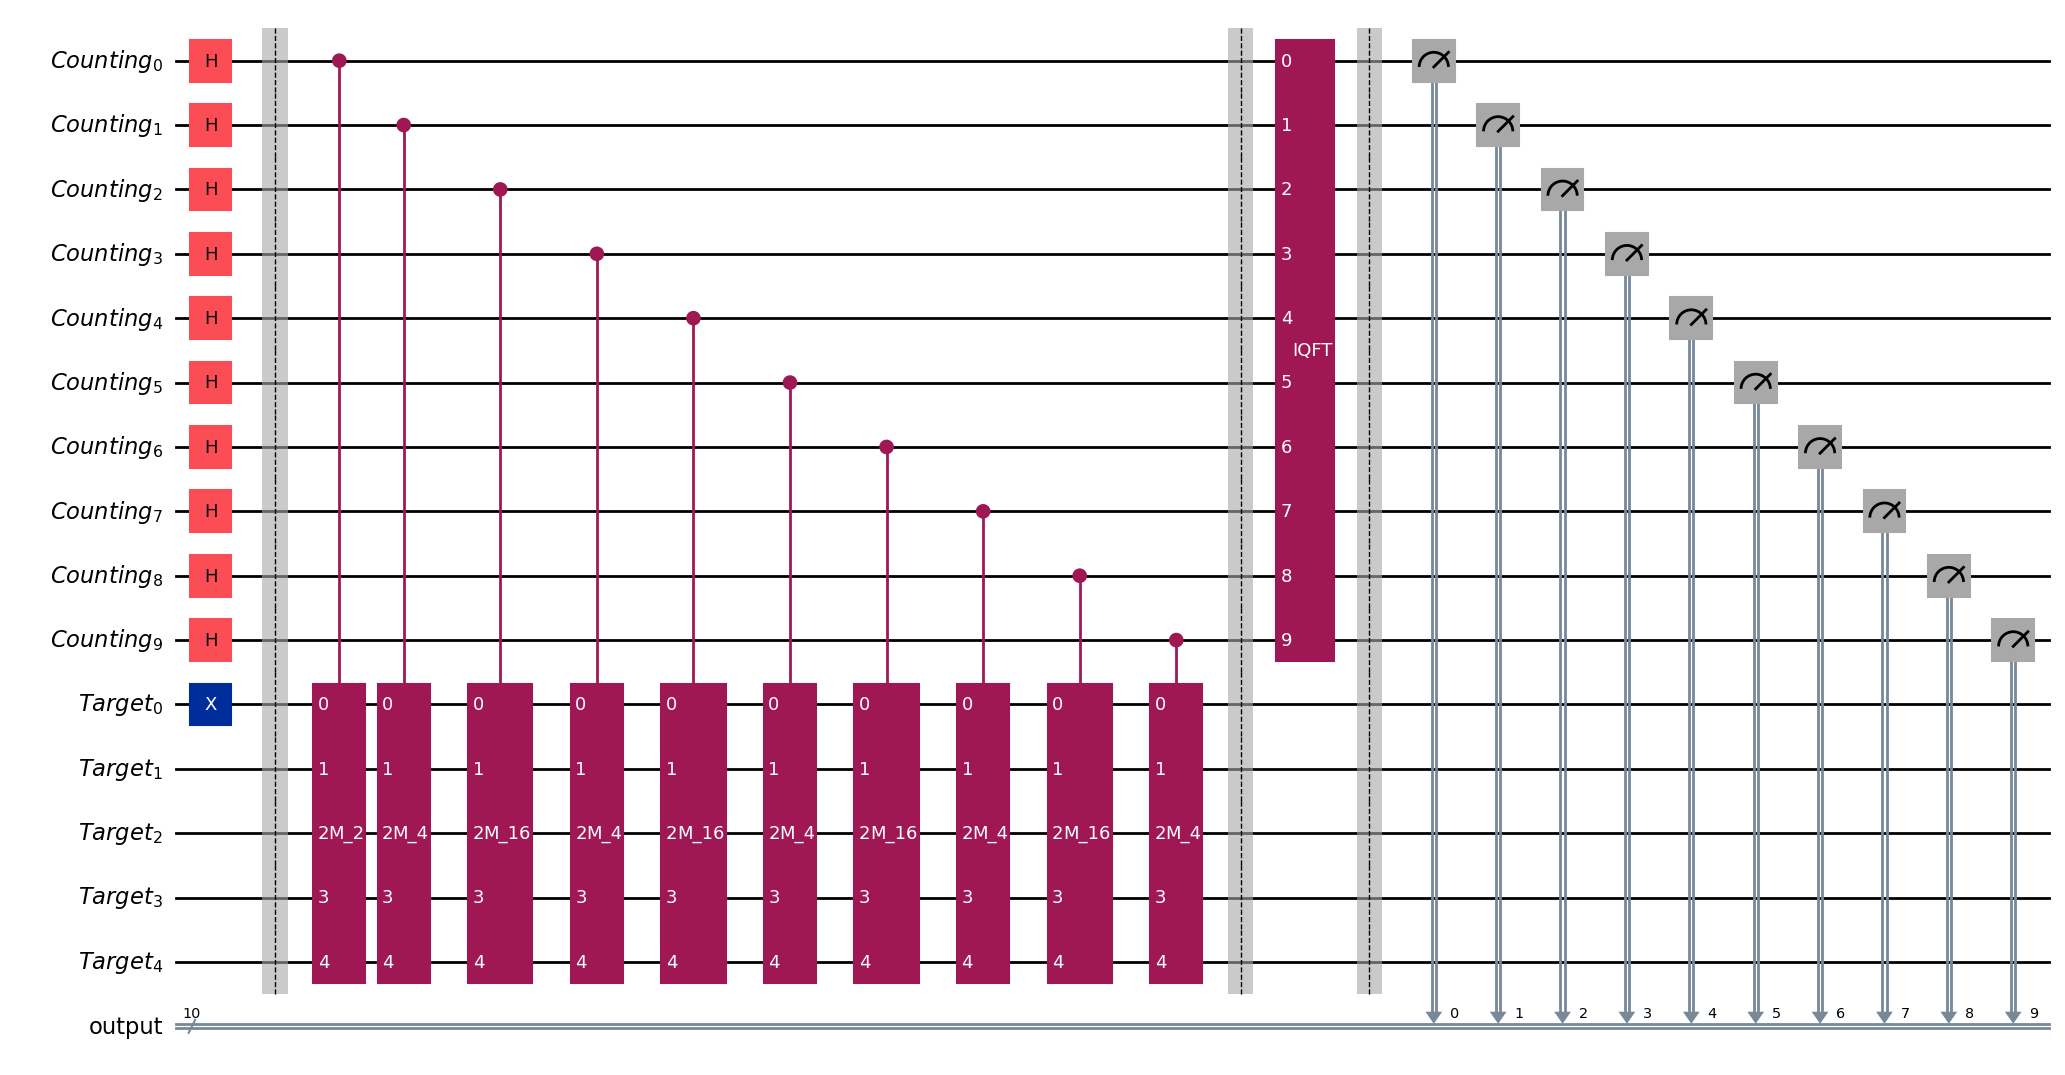

In [37]:
N = 21
a = 2
num_target = ceil(log(N, 2))         # 5 qubits
num_control = 2 * num_target          # 10 qubits

print(f"Shor's Algorithm Circuit: N={N}, a={a}")
print(f"Counting qubits: {num_control}, Target qubits: {num_target}")
print(f"Total qubits: {num_control + num_target}\n")

print("Counting qubit → Controlled multiplication:")
for k in range(num_control):
    power = pow(a, 2**k, N)
    skip = " (skip: identity)" if power == 1 else ""
    print(f"  Qubit {k}: a^(2^{k}) mod {N} = {a}^{2**k} mod {N} = {power}{skip}")

circuit_21, n_mults_21 = build_shor_circuit(N, a, num_control, num_target)

print(f"\nControlled multiplications applied: {n_mults_21}")
print(f"\nCircuit diagram:")
circuit_21.draw(output='mpl', fold=-1)

Transpiled circuit:
  Total gates: 26804
  Gate breakdown: {'u': 10204, 'cx': 10040, 'rz': 5591, 'u2': 840, 'cp': 45, 'u1': 27, 'h': 20, 'u3': 18, 'measure': 10, 'swap': 5, 'barrier': 3, 'x': 1}
  Circuit depth: 19767

  Simulation time: 9829.2 ms (4096 shots)
  Time per shot: 2.3997 ms


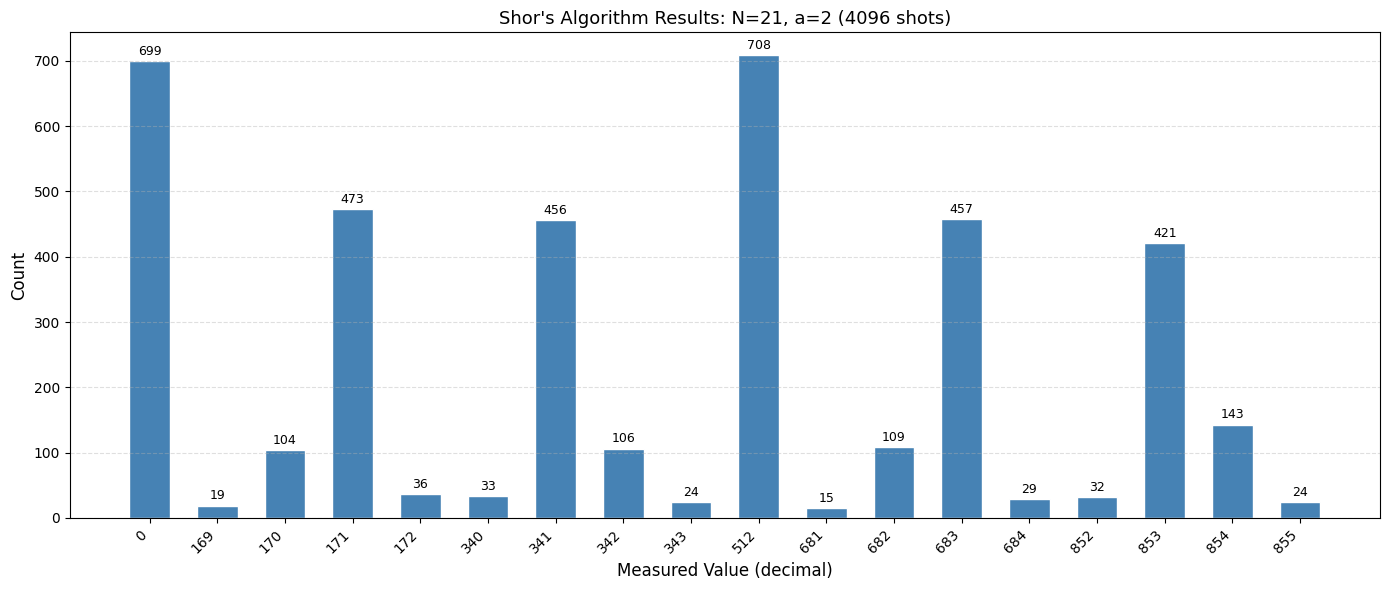

In [38]:
import matplotlib.pyplot as plt
backend = AerSimulator()
compiled_21 = transpile(circuit_21, backend, optimization_level=1)

print(f"Transpiled circuit:")
print(f"  Total gates: {sum(compiled_21.count_ops().values())}")
print(f"  Gate breakdown: {dict(compiled_21.count_ops())}")
print(f"  Circuit depth: {compiled_21.depth()}")

shots = 4096
start = time.perf_counter()
result = backend.run(compiled_21, shots=shots).result()
sim_time = (time.perf_counter() - start) * 1000

counts_21 = result.get_counts()
print(f"\n  Simulation time: {sim_time:.1f} ms ({shots} shots)")
print(f"  Time per shot: {sim_time/shots:.4f} ms")

# Convert binary bitstrings to decimal and filter low-count noise
decimal_counts = {int(k, 2): v for k, v in counts_21.items()}
filtered_counts = {k: v for k, v in sorted(decimal_counts.items()) if v > 10}

# Plot clean histogram
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(filtered_counts)), 
              list(filtered_counts.values()), 
              color='steelblue', edgecolor='white', width=0.6)

# Label each bar with its count
for bar, count in zip(bars, filtered_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=9)

# Use decimal values as x tick labels
ax.set_xticks(range(len(filtered_counts)))
ax.set_xticklabels([str(k) for k in filtered_counts.keys()], 
                    rotation=45, ha='right', fontsize=10)

ax.set_xlabel("Measured Value (decimal)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(f"Shor's Algorithm Results: N={N}, a={a} ({shots} shots)", fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [39]:
N, a = 21, 2
num_control_21 = 2 * ceil(log(N, 2))

# Phase table
rows_phase = []
for bitstring in sorted(counts_21, key=lambda x: counts_21[x], reverse=True):
    count = counts_21[bitstring]
    decimal = int(bitstring, 2)
    phase = decimal / (2**num_control_21)
    rows_phase.append([bitstring, decimal, count, f"{count/shots:.1%}",
                       f"{decimal}/{2**num_control_21} = {phase:.4f}"])

print(f"Phase extraction for N={N}, a={a}:")
df = pd.DataFrame(rows_phase[:15],
    columns=["Bitstring", "Decimal", "Count", "Probability", "Phase"])
print(df.to_string(index=False))

# Period and factor table
rows_period = []
success_shots_21 = 0

for bitstring in sorted(counts_21, key=lambda x: counts_21[x], reverse=True):
    count = counts_21[bitstring]
    decimal = int(bitstring, 2)
    phase = decimal / (2**num_control_21)
    frac = Fraction(phase).limit_denominator(N)
    r = frac.denominator
    valid = r > 1 and pow(a, r, N) == 1
    
    factors = ""
    if valid and r % 2 == 0:
        x = pow(a, r // 2, N)
        if x != N - 1:
            f1, f2 = gcd(x - 1, N), gcd(x + 1, N)
            if 1 < f1 < N:
                factors = f"{f1} × {N // f1}"
                success_shots_21 += count
            elif 1 < f2 < N:
                factors = f"{f2} × {N // f2}"
                success_shots_21 += count
    
    rows_period.append([f"{phase:.4f}", f"{frac.numerator}/{frac.denominator}",
                        r, "Yes" if valid else "No", count, factors if factors else "—"])

print(f"\nPeriod extraction and factoring for N={N}, a={a}:")
df = pd.DataFrame(rows_period[:15],
    columns=["Phase", "Fraction", "Guess for r", "Valid", "Count", "Factors"])
print(df.to_string(index=False))

print(f"\nSuccess rate: {100*success_shots_21/shots:.1f}% ({success_shots_21}/{shots} shots)")
if success_shots_21 > 0:
    print(f"Avg shots to first success: {round(shots/success_shots_21)}")

print(f"\nUnique outcomes: {len(counts_21)} out of {2**num_control_21} possible values")


Phase extraction for N=21, a=2:
 Bitstring  Decimal  Count Probability             Phase
1000000000      512    708       17.3% 512/1024 = 0.5000
0000000000        0    699       17.1%   0/1024 = 0.0000
0010101011      171    473       11.5% 171/1024 = 0.1670
1010101011      683    457       11.2% 683/1024 = 0.6670
0101010101      341    456       11.1% 341/1024 = 0.3330
1101010101      853    421       10.3% 853/1024 = 0.8330
1101010110      854    143        3.5% 854/1024 = 0.8340
1010101010      682    109        2.7% 682/1024 = 0.6660
0101010110      342    106        2.6% 342/1024 = 0.3340
0010101010      170    104        2.5% 170/1024 = 0.1660
0010101100      172     36        0.9% 172/1024 = 0.1680
0101010100      340     33        0.8% 340/1024 = 0.3320
1101010100      852     32        0.8% 852/1024 = 0.8320
1010101100      684     29        0.7% 684/1024 = 0.6680
1101010111      855     24        0.6% 855/1024 = 0.8350

Period extraction and factoring for N=21, a=2:
 Phase F

In [40]:
print("=" * 90)
print(f"SHOR'S ALGORITHM: N = 21 — ALL COPRIME BASES")
print("=" * 90)

N = 21
num_target = ceil(log(N, 2))
num_control = 2 * num_target
shots = 4096
bases_21 = [a for a in range(2, N) if gcd(a, N) == 1]

print(f"\nCoprime bases: {bases_21}")
print(f"Circuit: {num_control} counting + {num_target} target = {num_control + num_target} qubits, {shots} shots\n")

results_21 = []

for a in bases_21:
    val, true_r = a % N, 1
    while val != 1:
        val = (val * a) % N
        true_r += 1
    
    circuit, n_mults = build_shor_circuit(N, a, num_control, num_target)
    compiled = transpile(circuit, AerSimulator(), optimization_level=1)
    
    start = time.perf_counter()
    result = AerSimulator().run(compiled, shots=shots).result()
    sim_time = (time.perf_counter() - start) * 1000
    
    counts = result.get_counts()
    gate_counts = compiled.count_ops()
    
    success = 0
    factors_found = set()
    for bitstring, count in counts.items():
        phase = int(bitstring, 2) / (2**num_control)
        frac = Fraction(phase).limit_denominator(N)
        r = frac.denominator
        if r <= 1 or pow(a, r, N) != 1 or r % 2 != 0:
            continue
        x = pow(a, r // 2, N)
        if x == N - 1:
            continue
        f1, f2 = gcd(x - 1, N), gcd(x + 1, N)
        if 1 < f1 < N:
            factors_found.add((min(f1, N//f1), max(f1, N//f1)))
            success += count
        elif 1 < f2 < N:
            factors_found.add((min(f2, N//f2), max(f2, N//f2)))
            success += count
    
    sr = 100 * success / shots
    s2s = round(1 / (success/shots)) if success > 0 else None
    
    results_21.append({
        'a': a, 'true_r': true_r, 'n_mults': n_mults,
        'total_gates': sum(gate_counts.values()),
        'depth': compiled.depth(),
        'sim_time': sim_time,
        'success_rate': sr,
        'shots_to_1st': s2s,
        'factors': list(factors_found)
    })

rows = []
for r in results_21:
    f_str = str(r['factors'][0]) if r['factors'] else "—"
    s2s_str = str(r['shots_to_1st']) if r['shots_to_1st'] else "—"
    rows.append([r['a'], r['true_r'], r['n_mults'], r['total_gates'],
                 r['depth'], f"{r['sim_time']:.1f}", f"{r['success_rate']:.1f}%",
                 s2s_str, f_str])

df_21 = pd.DataFrame(rows,
    columns=["Base a", "Period r", "Ctrl Mults", "Total Gates", "Depth",
             "Sim Time (ms)", "Success Rate", "Shots to 1st", "Factors"])
print(df_21.to_string(index=False))

successful = [r for r in results_21 if r['factors']]
print(f"\nBases that found factors: {[r['a'] for r in successful]} ({len(successful)}/{len(bases_21)})")
if successful:
    print(f"Avg success rate: {np.mean([r['success_rate'] for r in successful]):.1f}%")

print(f"\nUnique outcomes: {len(counts_21)} out of {2**num_control_21} possible values")

SHOR'S ALGORITHM: N = 21 — ALL COPRIME BASES

Coprime bases: [2, 4, 5, 8, 10, 11, 13, 16, 17, 19, 20]
Circuit: 10 counting + 5 target = 15 qubits, 4096 shots



C:\Users\User\AppData\Local\Temp\ipykernel_25740\3769653115.py:71: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit.compose(QFT(num_control, inverse=True), qubits=control, inplace=True)


 Base a  Period r  Ctrl Mults  Total Gates  Depth Sim Time (ms) Success Rate Shots to 1st Factors
      2         6          10        26804  19767        9739.6        31.6%            3  (3, 7)
      4         3          10        26799  19763        9418.7         0.0%            —       —
      5         6          10        26802  19765        8242.1         0.0%            —       —
      8         2           1         2758   1993         379.9        50.0%            2  (3, 7)
     10         6          10        26801  19763        4327.1        32.3%            3  (3, 7)
     11         6          10        26800  19763       10094.4        32.6%            3  (3, 7)
     13         2           1         2757   1992         371.3        50.2%            2  (3, 7)
     16         3          10        26799  19763        9724.9         0.0%            —       —
     17         6          10        26800  19763        9924.2         0.0%            —       —
     19         6   

In [41]:
print("=" * 90)
print("QUANTUM SCALABILITY SUMMARY: N=15 vs N=21")
print("=" * 90)

for label, stored in [("N=15", results_15), ("N=21", results_21)]:
    successful = [r for r in stored if r['factors']]
    failed = [r for r in stored if not r['factors']]
    
    print(f"\n--- {label} ---")
    print(f"  Coprime bases tested:        {len(stored)}")
    print(f"  Bases that found factors:    {len(successful)} ({[r['a'] for r in successful]})")
    print(f"  Bases that failed:           {len(failed)} ({[r['a'] for r in failed]})")
    
    if successful:
        rows_summary = []
        rows_summary.append(["Success rate", f"{np.mean([r['success_rate'] for r in successful]):.1f}%"])
        rows_summary.append(["Avg shots to 1st success", f"{np.mean([r['shots_to_1st'] for r in successful if r['shots_to_1st']]):.1f}"])
        rows_summary.append(["Avg period r", f"{np.mean([r['true_r'] for r in successful]):.1f}"])
        rows_summary.append(["Avg ctrl multiplications", f"{np.mean([r['n_mults'] for r in successful]):.1f}"])
        rows_summary.append(["Avg total gates", f"{np.mean([r['total_gates'] for r in successful]):.0f}"])
        rows_summary.append(["Avg circuit depth", f"{np.mean([r['depth'] for r in successful]):.0f}"])
        rows_summary.append(["Avg simulation time", f"{np.mean([r['sim_time'] for r in successful]):.1f} ms"])
        
        df_summary = pd.DataFrame(rows_summary, columns=["Metric", "Value"])
        print(f"\n  Averages (successful bases):")
        print(df_summary.to_string(index=False))

# Growth comparison
s15 = [r for r in results_15 if r['factors']]
s21 = [r for r in results_21 if r['factors']]
if s15 and s21:
    print(f"\n--- Growth from N=15 to N=21 ---")
    rows_growth = []
    g15 = np.mean([r['total_gates'] for r in s15])
    g21 = np.mean([r['total_gates'] for r in s21])
    d15 = np.mean([r['depth'] for r in s15])
    d21 = np.mean([r['depth'] for r in s21])
    t15 = np.mean([r['sim_time'] for r in s15])
    t21 = np.mean([r['sim_time'] for r in s21])
    
    rows_growth.append(["Gate count", f"{g15:.0f}", f"{g21:.0f}", f"{g21/g15:.1f}x"])
    rows_growth.append(["Circuit depth", f"{d15:.0f}", f"{d21:.0f}", f"{d21/d15:.1f}x"])
    rows_growth.append(["Simulation time (ms)", f"{t15:.1f}", f"{t21:.1f}", f"{t21/t15:.1f}x"])
    
    df_growth = pd.DataFrame(rows_growth, columns=["Metric", "N=15", "N=21", "Growth"])
    print(df_growth.to_string(index=False))

QUANTUM SCALABILITY SUMMARY: N=15 vs N=21

--- N=15 ---
  Coprime bases tested:        7
  Bases that found factors:    6 ([2, 4, 7, 8, 11, 13])
  Bases that failed:           1 ([14])

  Averages (successful bases):
                  Metric   Value
            Success rate   49.6%
Avg shots to 1st success     2.0
            Avg period r     3.3
Avg ctrl multiplications     1.7
         Avg total gates    1075
       Avg circuit depth     752
     Avg simulation time 50.5 ms

--- N=21 ---
  Coprime bases tested:        11
  Bases that found factors:    6 ([2, 8, 10, 11, 13, 19])
  Bases that failed:           5 ([4, 5, 16, 17, 20])

  Averages (successful bases):
                  Metric     Value
            Success rate     38.2%
Avg shots to 1st success       2.7
            Avg period r       4.7
Avg ctrl multiplications       7.0
         Avg total gates     18788
       Avg circuit depth     13841
     Avg simulation time 5808.7 ms

--- Growth from N=15 to N=21 ---
             